In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('darkgrid')

In [4]:
data=pd.read_csv("Mall_Customers.csv")
df=pd.DataFrame(data)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [18]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Gender
Female    112
Male       88
Name: count, dtype: int64

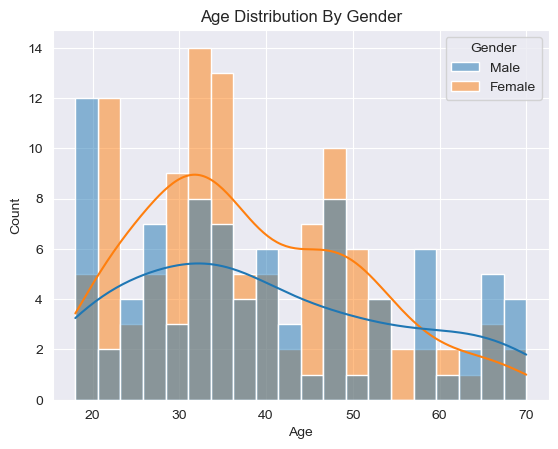

In [28]:
#fig,axes=plt.subplots(2,2,figsize=(14,7))
sns.histplot(data=df,x=df['Age'],bins=20,kde=True,hue=df['Gender']).set_title("Age Distribution By Gender") 
df['Gender'].value_counts()

**From this We see**
* The Mall has more number of Female customers than Male customers.

---

Gender
Female    5771
Male      4269
Name: Spending Score (1-100), dtype: int64

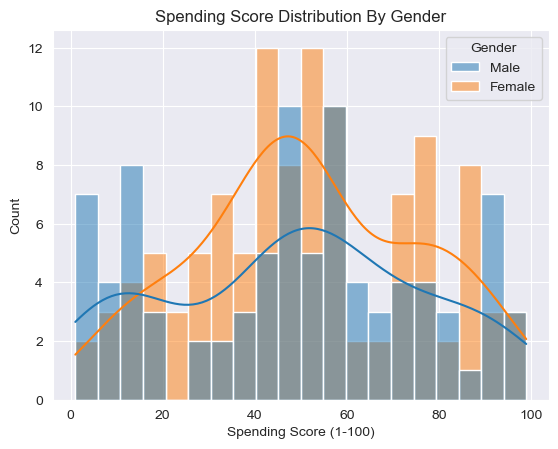

In [38]:
sns.histplot(data=df,x=df['Spending Score (1-100)'],bins=20, kde=True,hue=df['Gender']).set_title("Spending Score Distribution By Gender")
df.groupby(['Gender'])['Spending Score (1-100)'].sum()

* so here we clearly see that Females are more spending in Shopping.

  ---

Gender
Female    6636
Male      5476
Name: Annual Income (k$), dtype: int64

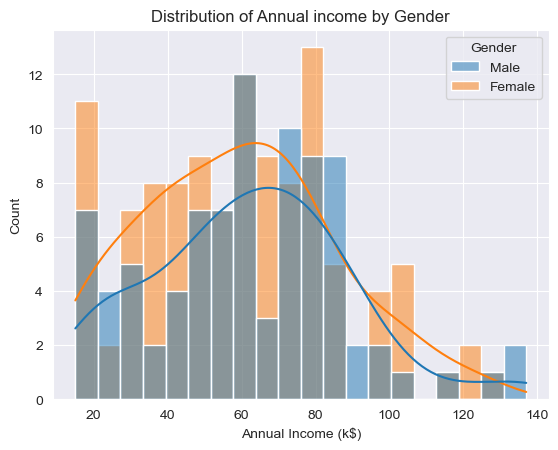

In [44]:
sns.histplot(data=df,x=df['Annual Income (k$)'],hue=df["Gender"],bins=20,kde=True).set_title("Distribution of Annual income by Gender")
df.groupby(df["Gender"])['Annual Income (k$)'].sum()

* So hear we See that
* females are spending more money over shopping & also there Income is higher Than Males

In [45]:
df.groupby(['Gender'])['Spending Score (1-100)'].sum()/df.groupby(df["Gender"])['Annual Income (k$)'].sum()

Gender
Female    0.869650
Male      0.779584
dtype: float64

* so here we can see that
* females are spending 86% of income
* males are spending 77% of income

In [46]:
# 1. Explore Gender vs. Spending Score
gender_spending_stats = df.groupby('Gender')['Spending Score (1-100)'].describe()
print("Summary Statistics for Spending Score by Gender:")
print(gender_spending_stats)


Summary Statistics for Spending Score by Gender:
        count       mean       std  min   25%   50%   75%   max
Gender                                                         
Female  112.0  51.526786  24.11495  5.0  35.0  50.0  73.0  99.0
Male     88.0  48.511364  27.89677  1.0  24.5  50.0  70.0  97.0


* *Slight Lead for Females*: On average, females have a slightly higher spending score ($51.53$) compared to males ($48.51$).

  ==========================================================

C:\Users\patil\AppData\Local\Temp\ipykernel_14248\137571464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set2')


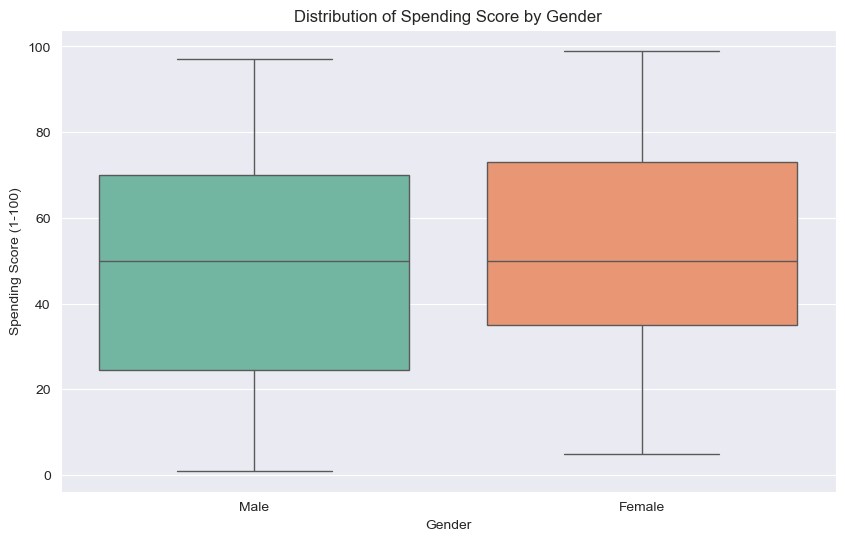

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set2')
plt.title('Distribution of Spending Score by Gender')
plt.savefig('gender_vs_spending_boxplot.png')

In [50]:
# 2. Feature Engineering
# Create a new feature: Spending Index (Annual Income * Spending Score)
# This represents a proxy for the absolute volume of spending relative to income level.
df['Spending_Index'] = (df['Annual Income (k$)'] * df['Spending Score (1-100)']) / 100

#clustering
features = ['Age', 'Spending_Index']
X = df[features]

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\patil\anaconda3\envs\sahilenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\patil\anaconda3\envs\sahilenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\patil\anaconda3\envs\sahilenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\patil\anaconda3\envs\sahilenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

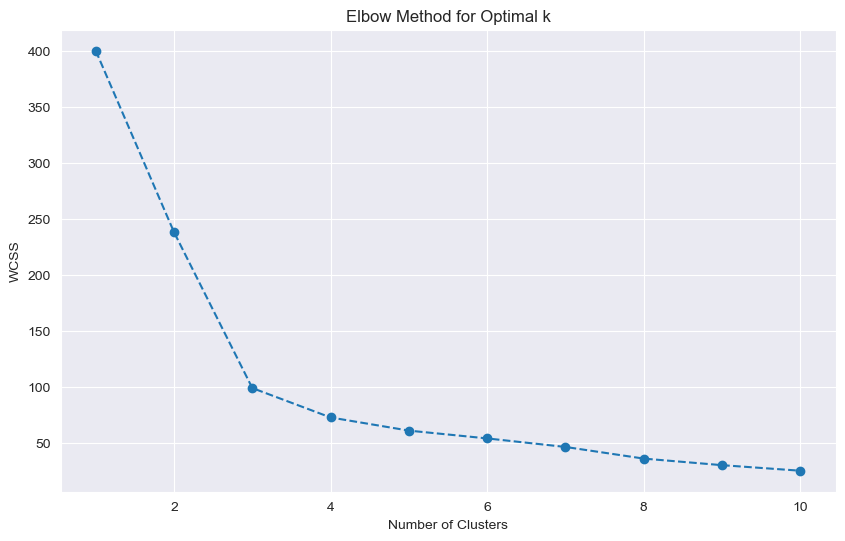

In [52]:
# Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.savefig('elbow_method.png')

C:\Users\patil\anaconda3\envs\sahilenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster Summary (Means):
               Age  Annual Income (k$)  Spending Score (1-100)  Spending_Index
Cluster                                                                       
0        61.685714           54.257143               38.857143       21.202571
1        32.692308           86.538462               82.128205       71.014103
2        24.508197           48.967213               53.081967       22.243607
3        43.707692           59.246154               34.446154       18.847538


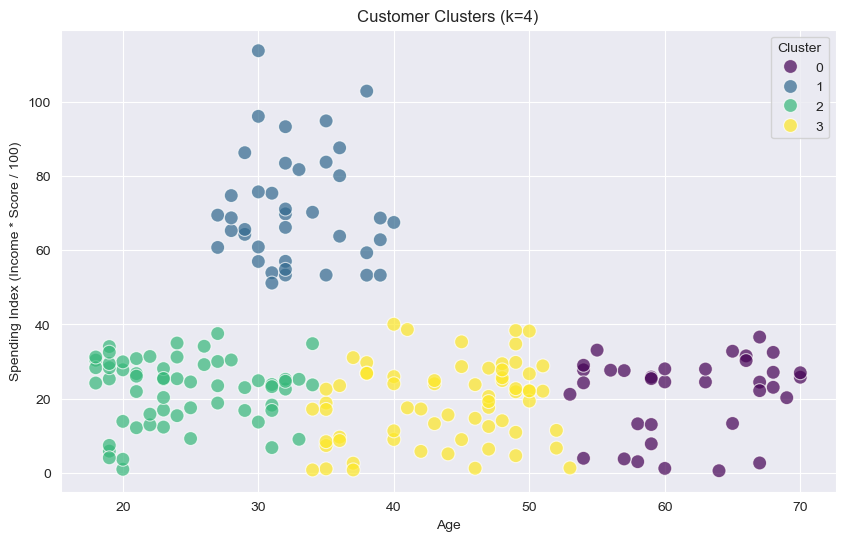

In [53]:
# Based on Elbow Method, let's pick k=4 (judging by common elbow patterns in this dataset)
# or I will determine it from the plot after running once. Usually it is 4 or 5.
k_optimal = 4 
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualization of clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Spending_Index', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title(f'Customer Clusters (k={k_optimal})')
plt.xlabel('Age')
plt.ylabel('Spending Index (Income * Score / 100)')
plt.legend(title='Cluster')
plt.savefig('cluster_visualization.png')

# Interpretation of clusters
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spending_Index']].mean()
print("\nCluster Summary (Means):")
print(cluster_summary)

**Observations**
  
* *Consistency*: Both genders share the exact same median spending score of $50$.
  
* *Volatility*: Males show a slightly higher standard deviation, indicating more variability in their spending habits (some very low and some very high spenders).
  
* *Conclusion*: Gender does not appear to be a primary driver of spending score in this dataset, as the distributions (as seen in the boxplot) overlap significantly.

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df['Gender_Numeric'] = df['Gender'].map({'Male': 0, 'Female': 1})
X = df[['Gender_Numeric', 'Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


Random Forest Performance:
Mean Squared Error: 459.34
R2 Score: 0.07


C:\Users\patil\AppData\Local\Temp\ipykernel_14248\73031850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')



Feature Importances:
              Feature  Importance
1                 Age    0.494180
2  Annual Income (k$)    0.474412
0      Gender_Numeric    0.031407


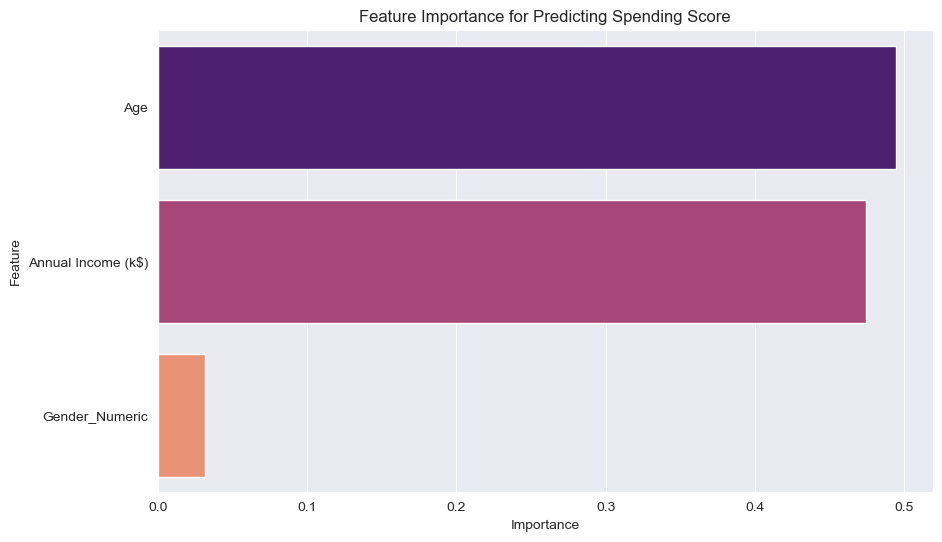

In [60]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance for Predicting Spending Score')
plt.savefig('feature_importance.png')

print("\nFeature Importances:")
print(feature_importance_df)